In [8]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
from langchain_huggingface import HuggingFacePipeline , ChatHuggingFace
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from pydantic import BaseModel,Field

In [10]:
LOCAL_MODEL_PATH = r"C:\Users\dell\.cache\huggingface\hub\models--TinyLlama--TinyLlama-1.1B-Chat-v1.0\snapshots\fe8a4ea1ffedaf415f4da2f062534de366a451e6"

tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    LOCAL_MODEL_PATH,
    torch_dtype="auto"
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    do_sample=True,
    temperature=0.7
)

llm = HuggingFacePipeline(pipeline=pipe)
model = ChatHuggingFace(llm=llm)

Device set to use cpu


In [12]:
# class Evaluation_schema(BaseModel):
    # score : int = Field(description='Score out of 10', ge=0, le=10)

In [13]:
# structured_mdoel = model.with_structured_output(Evaluation_schema)

In [ ]:
class Base_state(TypedDict):
    topic : str
    contain : str
    lang_score : int 
    clr_score : int 
    over_all_score : float
    

In [21]:
def llm_contain(state:Base_state):
    topic = state["topic"]
    prompt = f"write a eassy on the given {topic}"
    contain = model.invoke(prompt)
    state["contain"] = contain
    return state

In [22]:
def cal_lan_score(state:Base_state):
    topic = state["topic"]
    contain = state["contain"]
    prompt = f"give the score on the basis of language outof 10 for topic {topic} and descitpyion is \n {contain}"
    lang_score = model.invoke(prompt)
    return {"lang_score":lang_score}

In [23]:
def cal_clr_score(state:Base_state):
    topic = state["topic"]
    contain = state["contain"]
    prompt = f"give the score on the basis of clearity of thoughts outof 10 for topic {topic} and descitpyion is \n {contain}"
    clr_score = model.invoke(prompt)
    return {"clr_score":clr_score}


In [24]:
def cal_overall_score(state:Base_state):
    clr_score = state["clr_score"]
    lang_score = state["lang_score"]

    overall_score = (clr_score+lang_score)/2
    state["over_all_score"]= overall_score
    return state

In [25]:
graph = StateGraph(Base_state)

graph.add_node("llm_contain",llm_contain)
graph.add_node("cal_lan_score",cal_lan_score)
graph.add_node("cal_clr_score",cal_clr_score)
graph.add_node("cal_overall_score",cal_overall_score)

graph.add_edge(START,"llm_contain")
graph.add_edge("llm_contain","cal_lan_score")
graph.add_edge("llm_contain","cal_clr_score")
graph.add_edge("cal_lan_score","cal_overall_score")
graph.add_edge("cal_clr_score","cal_overall_score")
graph.add_edge("cal_overall_score",END)

workflow = graph.compile()

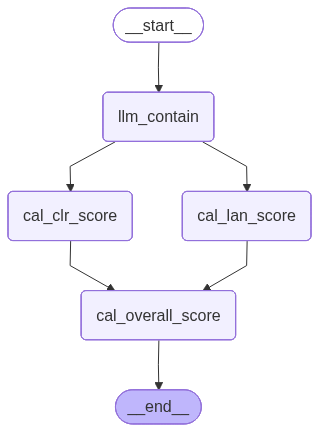

In [26]:
workflow

In [27]:
intial_state = {"topic":"cricket"}

final_state = workflow.invoke(intial_state)

print(final_state)

TypeError: unsupported operand type(s) for /: 'ChatPromptTemplate' and 'int'